**Question:** If there are 30 people in a room, what is the probability that everyone has different birthdays?

**My mathematical expression:** 365P30 / 365^30 ~ 0.303

**Logic**: 
- `365P30` counts the number of ways to assign birthdays to 30 distinct people such that all birthdays are different.

- `365^30` is the total number of ways to asign birthdays to 30 distinct people
___

# Part 1: Simulating Birthdays from a Uniform Distribution (1, 365)

Probability that everyone has a different birthday = 29.46%
Probability that at least two of the same birthday = 70.54%


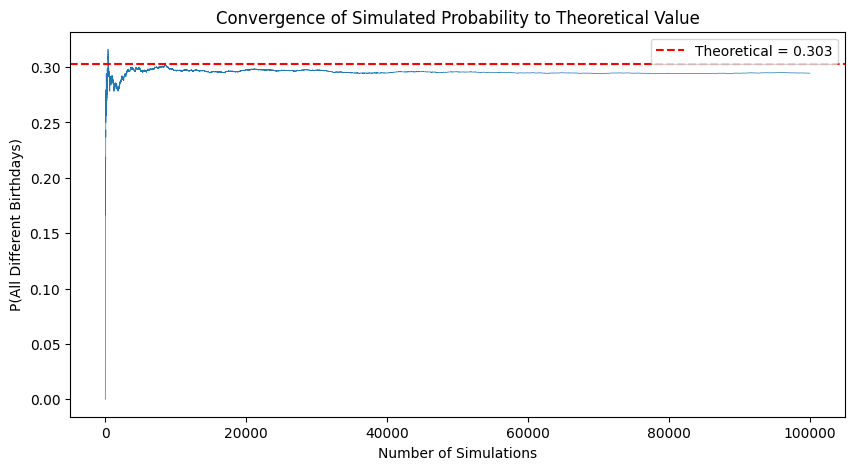

In [59]:
import random
import matplotlib.pyplot as plt

n = 30
simulations = 100000
success_trials = 0
probabilities = []

def single_trial(n):
    random_values_list = [random.randint(1, 365) for _ in range(n)]
    if len(set(random_values_list)) == n:
        return 1
    return 0

for i in range(1, simulations + 1):
    success_trials += single_trial(n)
    probabilities.append(success_trials / i)

print(f"Probability that everyone has a different birthday = {(success_trials/simulations)*100:.2f}%")
print(f"Probability that at least two of the same birthday = {(1-(success_trials/simulations))*100:.2f}%")
# Theoretical probability
theoretical = 0.303

plt.figure(figsize=(10, 5))
plt.plot(probabilities, linewidth=0.5)
plt.axhline(y=theoretical, color='r', linestyle='--', label=f'Theoretical = {theoretical}')
plt.xlabel('Number of Simulations')
plt.ylabel('P(All Different Birthdays)')
plt.title('Convergence of Simulated Probability to Theoretical Value')
plt.legend()
plt.show()

___
# Part 2: Simulating Birthdays from Real-World Data

In Part 1, birthdays were generated from a uniform distribution, X~ Uniform(1,365)

Now, I verify whether the birthday paradox still holds using real-world data.

The dataset was downloaded from:  
https://www.kaggle.com/datasets/mexwell/famous-birthdays?resource=download  

It contains approximately 4,700 famous individuals along with their birthdays.




In [60]:
import pandas as pd

df = pd.read_csv("birthdays.csv")

df.head(10)

,lastname,firstname,articleNum,birthDate,birthMonth,birthDay,zodiac
0,Aaliyah,NaN,0,1979-01-16,1.0,16.0,Capricorn
1,Aaron,Hank,46,1934-02-05,2.0,5.0,Aquarius
2,Abacha,Sani,2,1943-09-20,9.0,20.0,Virgo
3,Abbado,Claudio,9,1933-06-26,6.0,26.0,Cancer
4,Abbas,Mahmoud,306,1935-03-26,3.0,26.0,Aries
5,Abdel Rahman,Omar,21,1938-05-03,5.0,3.0,Taurus
6,Abdul-Jabbar,Kareem,11,1947-04-16,4.0,16.0,Aries
7,Abdul-Rauf,Mahmoud,0,1969-03-09,3.0,9.0,Pisces
8,Abdullah II,King of Jordan,1,1962-01-30,1.0,30.0,Aquarius
9,Abdullah,Abdullah,29,1960-01-01,1.0,1.0,Capricorn


**Data Preparation**

Rows with missing birthDate values are removed, and a new day_of_year column is created. The year 2000 is chosen to ensure that February 29 (leap day) is included and properly handled; otherwise, an error would occur when converting dates.

In [61]:
df = df.dropna(subset=["birthDate"])

df['day_of_year'] = pd.to_datetime(
    '2000-' + df['birthMonth'].astype(int).astype(str) + '-' + df['birthDay'].astype(int).astype(str)
).dt.dayofyear

**Data Visualization**

<Axes: xlabel='day_of_year', ylabel='Count'>

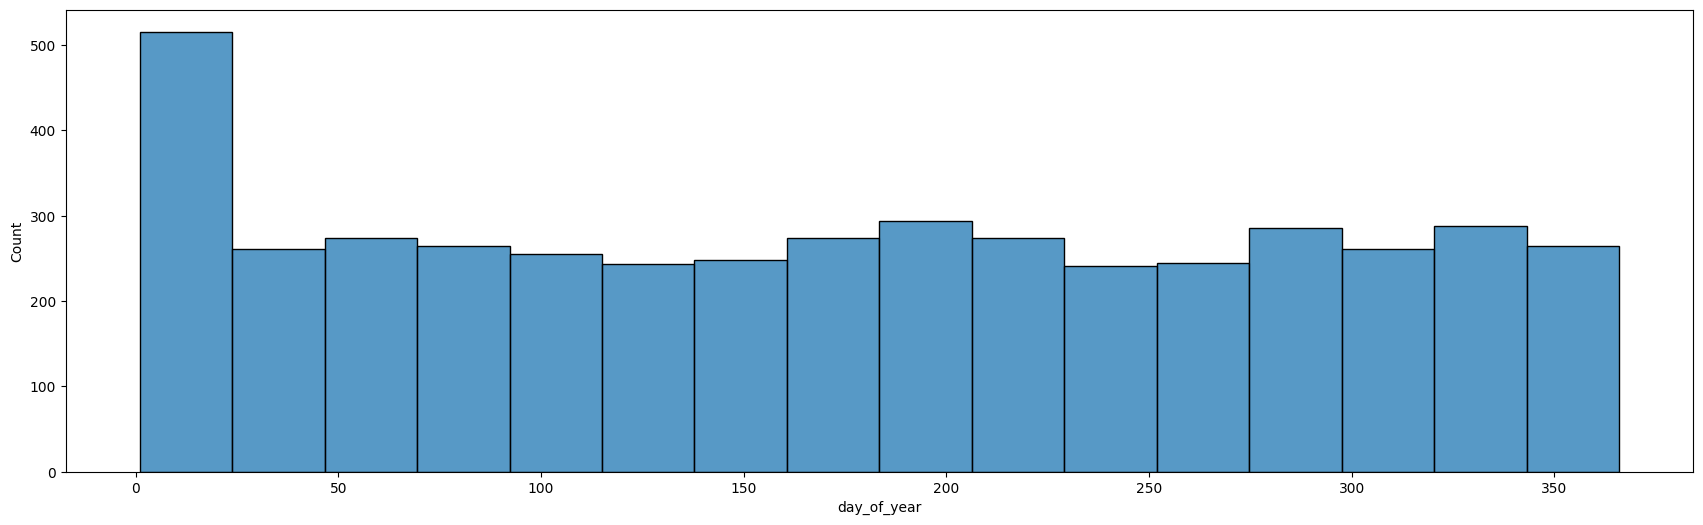

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(21,6))
sns.histplot(df["day_of_year"])

**Data Cleaning**

The histogram revealed an abnormal spike in early January. Upon investigation, a disproportionate number of entries have a birth date of January 1st across many different years. These are likely placeholder values assigned when only the birth year was known. To avoid skewing the analysis, all January 1st entries are excluded.

With this exclusion, the sample space reduces from 365 to 364 possible birthdays. 

The probability that all 30 people in a group have distinct birthdays becomes 364P30 / 364^30 ~ 0.2927

<Axes: xlabel='day_of_year', ylabel='Count'>

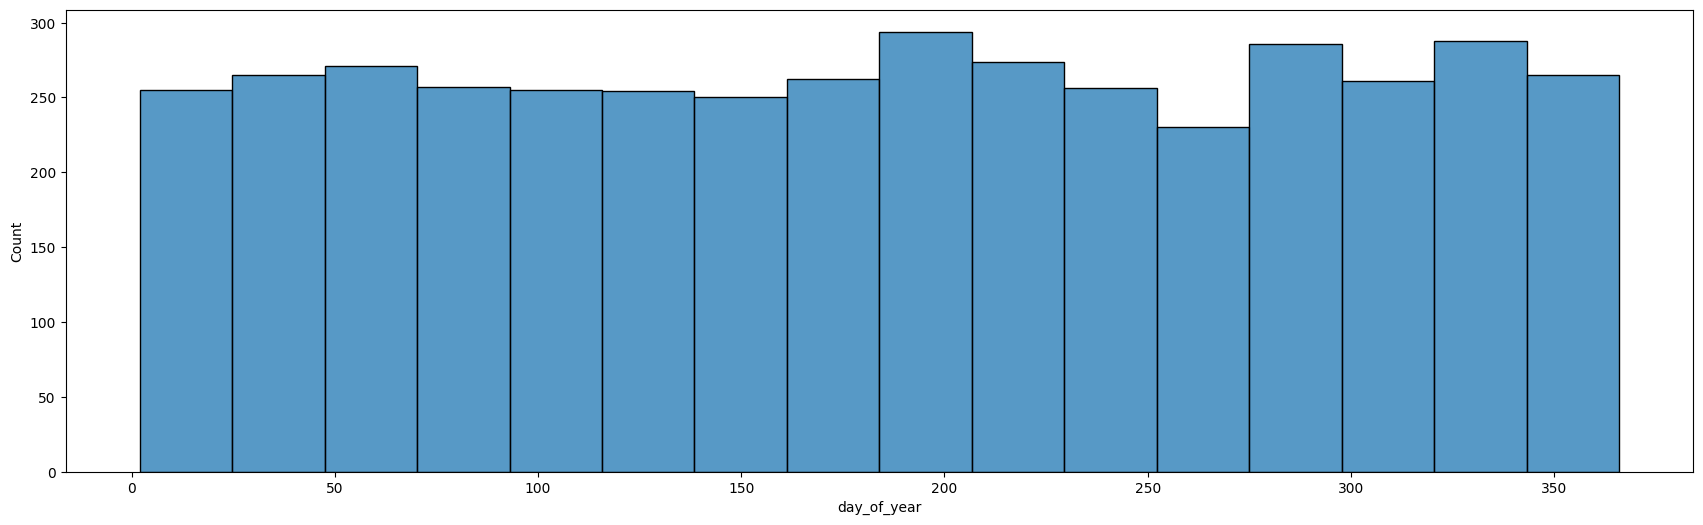

In [63]:
df = df[df['day_of_year'] != 1]
plt.figure(figsize=(21,6))
sns.histplot(df["day_of_year"])

Probability that everyone has a different birthday = 29.15%
Probability that at least two of the same birthday = 70.85%


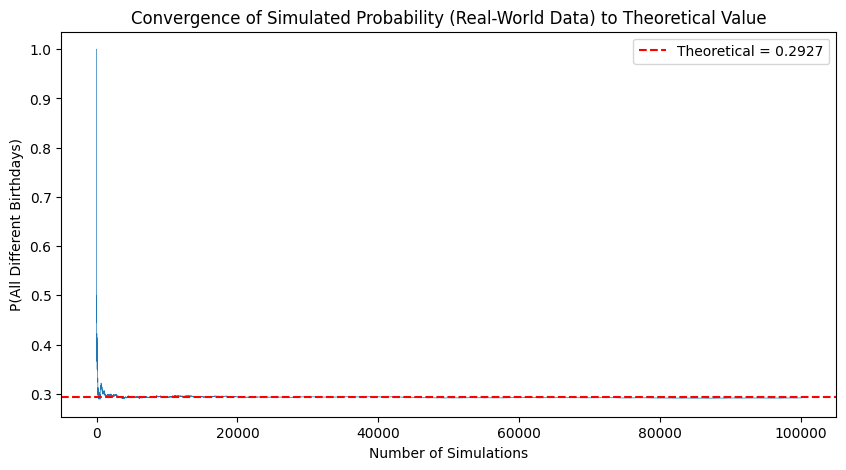

In [64]:
import numpy as np
import matplotlib.pyplot as plt

n = 30
simulations = 100000
success_trials = 0
probabilities = []
np.random.seed(42)

def single_trial(n):
    random_values_list = df["day_of_year"].sample(n=n)
    if len(set(random_values_list)) == n:
        return 1
    return 0

for i in range(1, simulations + 1):
    success_trials += single_trial(n)
    probabilities.append(success_trials / i)

theoretical = 0.2927

print(f"Probability that everyone has a different birthday = {(success_trials/simulations)*100:.2f}%")
print(f"Probability that at least two of the same birthday = {(1-(success_trials/simulations))*100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(probabilities, linewidth=0.5)
plt.axhline(y=theoretical, color='r', linestyle='--', label=f'Theoretical = {theoretical}')
plt.xlabel('Number of Simulations')
plt.ylabel('P(All Different Birthdays)')
plt.title('Convergence of Simulated Probability (Real-World Data) to Theoretical Value')
plt.legend()
plt.show()

**The simulated probability result of 29.15% is very close to the calculated probability result of 29.27% dervied with mathematical probability.**